# 探索性数据分析（EDA）
## Brazilian E-Commerce 数据集

**目标**：快速了解数据结构、发现异常、找到后续分析的切入点




规模 │ 有几张表？每张表多少行？
时间 │ 订单和买家随时间怎么变化？有没有季节性？
画像 │ 用户怎么付款？评分分布怎么样？  

In [9]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import config
import sqlite3
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ── 先把 seaborn 风格设好 ──
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

# ── 再设中文字体（必须放在 sns.set_style 之后！否则会被覆盖）──
# 用 font.sans-serif 列表 + 重新 build 字体缓存，双保险
import matplotlib.font_manager as fm
# 删除旧缓存
import glob
_cache_dir = matplotlib.get_cachedir()
for _f in glob.glob(os.path.join(_cache_dir, 'fontlist*.json')):
    try: os.remove(_f)
    except: pass
# 强制重建字体列表
fm._load_fontmanager(try_read_cache=False)

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Noto Sans SC']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

In [10]:
# 连接数据库
# sqlite3.connect(config.DB_PATH) 等价于：
# 
#   sqlite3.connect("C:/Users/86139/ecommerce-analysis/data/olist.db")

conn = sqlite3.connect(config.DB_PATH)

# 查看所有表
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
print(f"数据库包含 {len(tables)} 张表:")
tables
# customers                    │ 客户信息                                  │
#   ├──────────────────────────────┼───────────────────────────────────────────┤
#   │ geolocation                  │ 巴西邮政编码经纬度（72 万行，最大的一张） │
#   ├──────────────────────────────┼───────────────────────────────────────────┤
#   │ order_items                  │ 订单商品明细                              │
#   ├──────────────────────────────┼───────────────────────────────────────────┤
#   │ order_payments               │ 支付记录                                  │
#   ├──────────────────────────────┼───────────────────────────────────────────┤
#   │ order_reviews                │ 评论                                      │
#   ├──────────────────────────────┼───────────────────────────────────────────┤
#   │ orders                       │ 订单主表                                  │
#   ├──────────────────────────────┼───────────────────────────────────────────┤
#   │ product_category_translation │ 品类名葡萄牙语→英文翻译                   │
#   ├──────────────────────────────┼───────────────────────────────────────────┤
#   │ products                     │ 商品信息                                  │
#   ├──────────────────────────────┼───────────────────────────────────────────┤
#   │ sellers                      │ 卖家信息  

数据库包含 9 张表:


,name
0,customers
1,geolocation
2,order_items
3,order_payments
4,order_reviews
5,orders
6,product_category_translation
7,products
8,sellers


In [11]:
# 各表数据量
for t in tables['name']:
    n = pd.read_sql(f"SELECT COUNT(*) AS cnt FROM [{t}]", conn)['cnt'][0]
    cols = pd.read_sql(f"PRAGMA table_info([{t}])", conn)['name'].tolist()
    print(f"  {t:35s}  {n:>8,d} 行  |  {len(cols)} 列")

  customers                              96,096 行  |  5 列
  geolocation                           720,154 行  |  5 列
  order_items                           112,650 行  |  7 列
  order_payments                        103,886 行  |  5 列
  order_reviews                          99,224 行  |  7 列
  orders                                 99,441 行  |  8 列
  product_category_translation               71 行  |  2 列
  products                               32,951 行  |  9 列
  sellers                                 3,095 行  |  4 列


### 1. 订单时间趋势

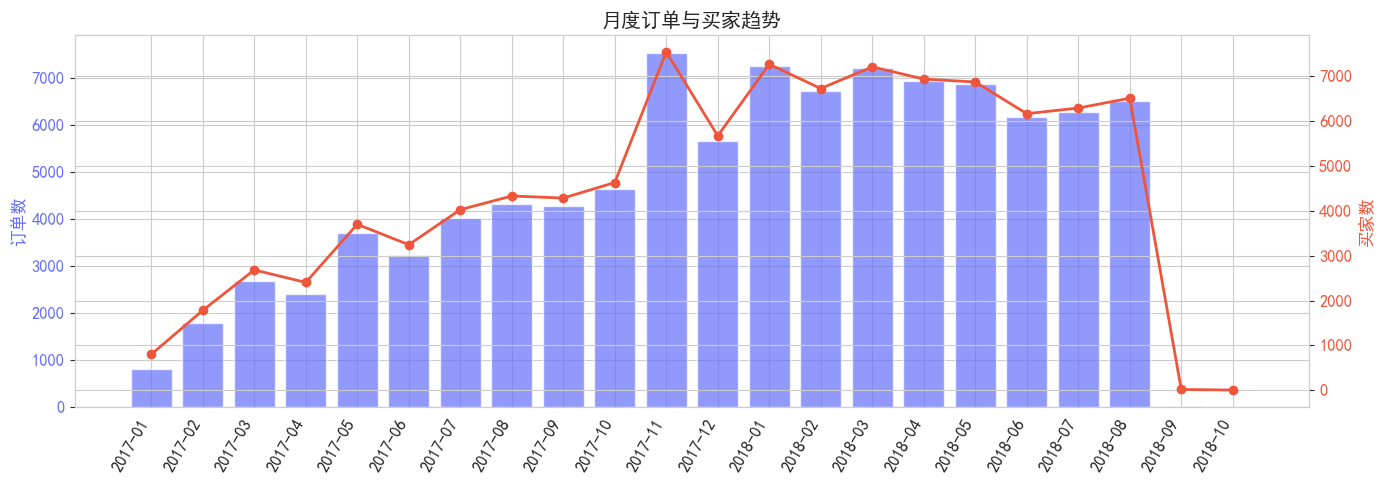

In [12]:
orders_over_time = pd.read_sql("""
    SELECT
        strftime('%Y-%m', order_purchase_timestamp) AS month,
        COUNT(*) AS order_count,
        COUNT(DISTINCT customer_id) AS buyer_count
    FROM orders
    WHERE order_purchase_timestamp >= '2017-01-01'
    GROUP BY month
    ORDER BY month
""", conn)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(orders_over_time['month'], orders_over_time['order_count'], alpha=0.7, color='#636EFA')
ax1.set_ylabel('订单数', color='#636EFA')
ax1.tick_params(axis='y', labelcolor='#636EFA')
ax1.set_xticks(range(len(orders_over_time['month'])), labels=orders_over_time['month'], rotation=60, ha='right')

ax2 = ax1.twinx()
ax2.plot(orders_over_time['month'], orders_over_time['buyer_count'], color='#EF553B', linewidth=2, marker='o')
ax2.set_ylabel('买家数', color='#EF553B')
ax2.tick_params(axis='y', labelcolor='#EF553B')
plt.title('月度订单与买家趋势')
plt.tight_layout()
plt.show()

#2017 年底到 2018 年初有明显高峰（可能是黑五/圣诞季）

### 2. 支付方式分布

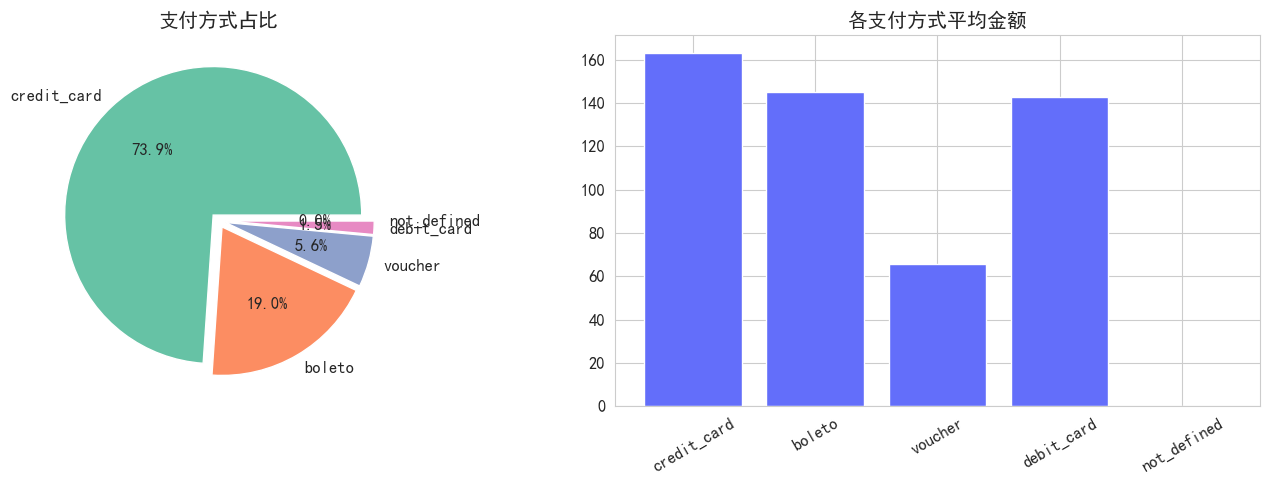

In [13]:
payments = pd.read_sql("""
    SELECT
        payment_type,
        COUNT(*) AS cnt,
        ROUND(AVG(payment_value), 2) AS avg_value
    FROM order_payments
    GROUP BY payment_type
    ORDER BY cnt DESC
""", conn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie(payments['cnt'], labels=payments['payment_type'], autopct='%1.1f%%', explode=[0.05]*len(payments))
axes[0].set_title('支付方式占比')
axes[1].bar(payments['payment_type'], payments['avg_value'], color='#636EFA')
axes[1].set_title('各支付方式平均金额')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 3. 评分分布

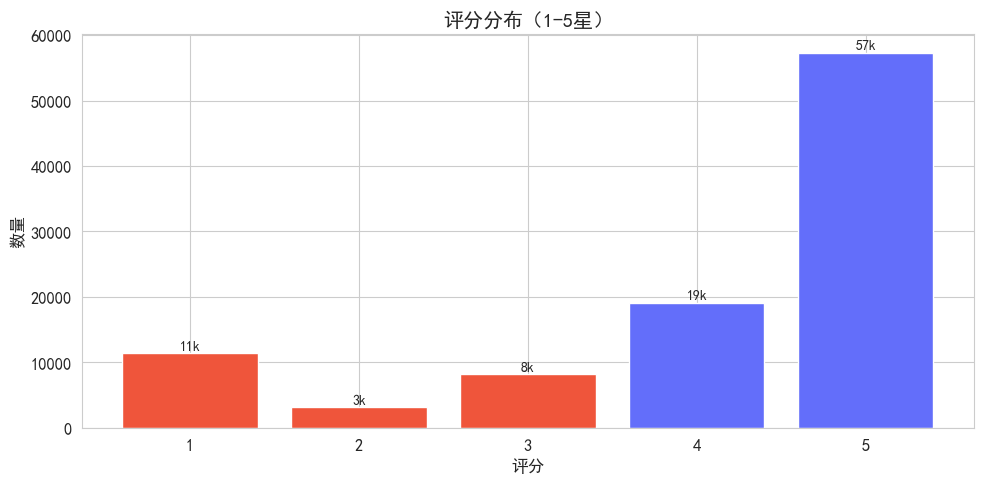

In [14]:
reviews = pd.read_sql("SELECT review_score, COUNT(*) AS cnt FROM order_reviews GROUP BY review_score ORDER BY review_score", conn)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#EF553B' if s <= 3 else '#636EFA' if s >= 4 else '#FFA15A' for s in reviews['review_score']]
ax.bar(reviews['review_score'], reviews['cnt'], color=colors)
ax.set_title('评分分布（1-5星）')
ax.set_xlabel('评分')
ax.set_ylabel('数量')
for i, (score, cnt) in enumerate(zip(reviews['review_score'], reviews['cnt'])):
    ax.text(score, cnt + 500, f'{cnt/1000:.0f}k', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [15]:
conn.close()
print('EDA 完成 — 数据时间跨度 2016-09 至 2018-10，信用卡是主要支付方式，评分集中在 4-5 星。')

EDA 完成 — 数据时间跨度 2016-09 至 2018-10，信用卡是主要支付方式，评分集中在 4-5 星。
